<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 700; line-height: 1.2;">
        Manejo de Variables Categóricas (Handling Categorical Variables)
      </h1>
      <p style="margin: 6px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Programación para Ciencia de Datos | Módulo 06: Feature Engineering
      </p>
    </td>
    <td style="vertical-align: middle; text-align: right; border: none; padding: 15px 20px; min-width: 240px; font-family: system-ui, -apple-system, sans-serif;">
      <div style="font-size: 0.9em; color: #334155; line-height: 1.5;">
        <strong style="color: #1e3a8a; font-size: 1em;">Especialización en Ciencia de Datos</strong><br>
        <span style="color: #475569; font-weight: 600;">USTA Tunja</span><br><br>
        <b>Santiago A. Zúñiga M.</b><br>
        ✉️ <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
      </div>
    </td>
  </tr>
</table>

---
## ¿Qué es la Ingeniería de Características? (*What is Feature Engineering?*) ⚙️

La **Ingeniería de Características (Feature Engineering)** es el proceso de transformar datos sin procesar (*raw data*) en un formato más adecuado para los modelos de Machine Learning. 

Involucra la creación de nuevas características, la selección de variables relevantes y la transformación de características existentes para mejorar el rendimiento de un modelo en términos de **precisión** e **interpretabilidad**. Es una etapa crítica en el pipeline de preprocesamiento de datos y juega un rol fundamental en potenciar el poder predictivo de los algoritmos de aprendizaje automático.

---
### 1. Configuración del Entorno (*Setup the notebook*) 🛠️

Cargamos las librerías necesarias para la manipulación de datos, transformaciones de Scikit-Learn y modelado predictivo:

In [57]:
# Visualización y cálculo numérico
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Modelado, división y evaluación
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Técnicas de codificación y reducción de dimensionalidad
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from IPython.display import display

# Configuración interactiva para Jupyter
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


---
### Manejo de Variables Categóricas (*Handling categorical variables*) 🏷️

Una **variable categórica** toma solo un número limitado de valores.

- Considera una encuesta que pregunta con qué frecuencia desayunas y ofrece cuatro opciones: *"Never"* (Nunca), *"Rarely"* (Rara vez), *"Most days"* (Casi siempre) o *"Every day"* (Todos los días). En este caso, los datos son categóricos porque las respuestas caen dentro de un conjunto fijo de categorías.
- Si las personas respondieran a una encuesta sobre qué marca de automóvil poseen, las respuestas caerían en categorías como *"Honda"*, *"Toyota"* y *"Ford"*. En este caso, los datos también son categóricos.

> ⚠️ Obtendrás un error si intentas introducir estas variables directamente en la mayoría de los modelos de Machine Learning en Python sin preprocesarlas primero. 
>
> A continuación comparamos tres enfoques básicos que puedes utilizar para preparar tus datos categóricos:

### Los Tres Enfoques Básicos 🧭

#### 1) Eliminar Variables Categóricas (*Drop Categorical Variables*)
El enfoque más simple para lidiar con variables categóricas es simplemente removerlas del conjunto de datos. Este enfoque solo funcionará bien si las columnas no contenían información útil.

#### 2) Codificación Ordinal (*Ordinal Encoding*)
La codificación ordinal asigna a cada valor único un número entero diferente.

<div align="center">
<table style="width: 100%; max-width: 480px; border-collapse: separate; border-spacing: 0; font-family: system-ui, -apple-system, sans-serif; font-size: 14px; background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 10px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.05);">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff;">
      <th style="padding: 12px 16px; text-align: left; font-weight: 600; border-bottom: 1px solid #e2e8f0;">Breakfast (Original)</th>
      <th style="padding: 12px 16px; text-align: center; font-weight: 600; border-bottom: 1px solid #e2e8f0; width: 160px;">Breakfast (Encoded)</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; text-align: left; color: #0f172a; font-weight: 500; border-bottom: 1px solid #f1f5f9;">Every day</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9;">
        <span style="background-color: #e0e7ff; color: #3730a3; font-weight: 700; padding: 3px 12px; border-radius: 12px; display: inline-block;">3</span>
      </td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 10px 16px; text-align: left; color: #0f172a; font-weight: 500; border-bottom: 1px solid #f1f5f9;">Never</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9;">
        <span style="background-color: #e0e7ff; color: #3730a3; font-weight: 700; padding: 3px 12px; border-radius: 12px; display: inline-block;">0</span>
      </td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; text-align: left; color: #0f172a; font-weight: 500; border-bottom: 1px solid #f1f5f9;">Rarely</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9;">
        <span style="background-color: #e0e7ff; color: #3730a3; font-weight: 700; padding: 3px 12px; border-radius: 12px; display: inline-block;">1</span>
      </td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 10px 16px; text-align: left; color: #0f172a; font-weight: 500; border-bottom: 1px solid #f1f5f9;">Most days</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9;">
        <span style="background-color: #e0e7ff; color: #3730a3; font-weight: 700; padding: 3px 12px; border-radius: 12px; display: inline-block;">2</span>
      </td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; text-align: left; color: #0f172a; font-weight: 500;">Never</td>
      <td style="padding: 10px 16px; text-align: center;">
        <span style="background-color: #e0e7ff; color: #3730a3; font-weight: 700; padding: 3px 12px; border-radius: 12px; display: inline-block;">0</span>
      </td>
    </tr>
  </tbody>
</table>
</div>

Este enfoque asume un ordenamiento de las categorías:
$$\text{"Never" (0)} < \text{"Rarely" (1)} < \text{"Most days" (2)} < \text{"Every day" (3)}$$

Esta suposición tiene sentido en este ejemplo, porque existe un ranking indiscutible entre las categorías. No todas las variables categóricas tienen un orden claro en sus valores, pero a aquellas que sí lo tienen las denominamos **variables ordinales**. Para modelos basados en árboles (como árboles de decisión y *random forests*), puedes esperar que la codificación ordinal funcione muy bien con variables ordinales.

#### 3) Codificación One-Hot (*One-Hot Encoding*)
One-hot encoding crea nuevas columnas indicando la **presencia (1)** o **ausencia (0)** de cada valor posible en los datos originales. Para entender esto, trabajemos con un ejemplo:

<div align="center" style="margin-bottom: 30px;">
<table style="width: 100%; max-width: 520px; border-collapse: separate; border-spacing: 0; font-family: system-ui, -apple-system, sans-serif; font-size: 14px; background-color: #ffffff; border: 1px solid #e2e8f0; border-radius: 10px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.05);">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff;">
      <th style="padding: 12px 16px; text-align: left; font-weight: 600; border-bottom: 1px solid #e2e8f0;">Color (Original)</th>
      <th style="padding: 12px 16px; text-align: center; font-weight: 600; border-bottom: 1px solid #e2e8f0; width: 80px;">Red</th>
      <th style="padding: 12px 16px; text-align: center; font-weight: 600; border-bottom: 1px solid #e2e8f0; width: 80px;">Yellow</th>
      <th style="padding: 12px 16px; text-align: center; font-weight: 600; border-bottom: 1px solid #e2e8f0; width: 80px;">Green</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; text-align: left; border-bottom: 1px solid #f1f5f9;">
        <span style="background-color: #fef2f2; color: #991b1b; font-weight: 600; padding: 3px 10px; border-radius: 6px; border: 1px solid #fecaca;">Red</span>
      </td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9;"><span style="background-color: #dbeafe; color: #1e40af; font-weight: 700; padding: 2px 8px; border-radius: 12px;">1</span></td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9; color: #94a3b8;">0</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9; color: #94a3b8;">0</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 10px 16px; text-align: left; border-bottom: 1px solid #f1f5f9;">
        <span style="background-color: #fef2f2; color: #991b1b; font-weight: 600; padding: 3px 10px; border-radius: 6px; border: 1px solid #fecaca;">Red</span>
      </td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9;"><span style="background-color: #dbeafe; color: #1e40af; font-weight: 700; padding: 2px 8px; border-radius: 12px;">1</span></td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9; color: #94a3b8;">0</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9; color: #94a3b8;">0</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; text-align: left; border-bottom: 1px solid #f1f5f9;">
        <span style="background-color: #fefce8; color: #854d0e; font-weight: 600; padding: 3px 10px; border-radius: 6px; border: 1px solid #fef08a;">Yellow</span>
      </td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9; color: #94a3b8;">0</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9;"><span style="background-color: #dbeafe; color: #1e40af; font-weight: 700; padding: 2px 8px; border-radius: 12px;">1</span></td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9; color: #94a3b8;">0</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 10px 16px; text-align: left; border-bottom: 1px solid #f1f5f9;">
        <span style="background-color: #f0fdf4; color: #166534; font-weight: 600; padding: 3px 10px; border-radius: 6px; border: 1px solid #bbf7d0;">Green</span>
      </td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9; color: #94a3b8;">0</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9; color: #94a3b8;">0</td>
      <td style="padding: 10px 16px; text-align: center; border-bottom: 1px solid #f1f5f9;"><span style="background-color: #dbeafe; color: #1e40af; font-weight: 700; padding: 2px 8px; border-radius: 12px;">1</span></td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; text-align: left;">
        <span style="background-color: #fefce8; color: #854d0e; font-weight: 600; padding: 3px 10px; border-radius: 6px; border: 1px solid #fef08a;">Yellow</span>
      </td>
      <td style="padding: 10px 16px; text-align: center; color: #94a3b8;">0</td>
      <td style="padding: 10px 16px; text-align: center;"><span style="background-color: #dbeafe; color: #1e40af; font-weight: 700; padding: 2px 8px; border-radius: 12px;">1</span></td>
      <td style="padding: 10px 16px; text-align: center; color: #94a3b8;">0</td>
    </tr>
  </tbody>
</table>
</div>

En el dataset original, *"Color"* es una variable categórica con tres categorías: *"Red"*, *"Yellow"* y *"Green"*. La codificación one-hot correspondiente contiene una columna para cada valor posible, y una fila por cada observación original. Donde el valor original era *"Red"*, colocamos un 1 en la columna *"Red"*; si el valor era *"Yellow"*, colocamos un 1 en la columna *"Yellow"*, y así sucesivamente.

En contraste con la codificación ordinal, **one-hot encoding no asume un ordenamiento** de las categorías. Por tanto, puedes esperar que este enfoque funcione particularmente bien si no existe un orden claro en los datos categóricos (ej., *"Red"* no es más ni menos que *"Yellow"*). A estas variables las denominamos **variables nominales**.

One-hot encoding generalmente no tiene un buen rendimiento si la variable toma una gran cantidad de valores (generalmente **no se usa para variables con más de 15 valores diferentes**).

---
### 2. Ejemplo Práctico con el Dataset de Melbourne Housing (*Example*) 🏠

Trabajaremos con el dataset de viviendas de Melbourne (*Melbourne Housing*).

No nos enfocaremos en la etapa de carga de datos. En su lugar, imagina que estás en un punto donde ya tienes los datos de entrenamiento y validación preparados en `X_train`, `X_valid`, `y_train` e `y_valid`:

In [58]:
import os
import urllib.request

# --- Carga de Datos con Resolución de Rutas y Fallback ---
file_path = 'data/melb_data.csv'
if not os.path.exists(file_path) and os.path.exists(f'06 - Feature Engineering/{file_path}'):
    file_path = f'06 - Feature Engineering/{file_path}'

if not os.path.exists(file_path):
    print('Descargando dataset melb_data.csv...')
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    url = 'https://raw.githubusercontent.com/ricber/data-science-course/master/06-Feature%20Engineering/data/melb_data.csv'
    urllib.request.urlretrieve(url, file_path)
# --------------------------------------------------------

# Leemos los datos
data = pd.read_csv(file_path)

# Separamos la variable objetivo de los predictores
y = data.Price
X = data.drop(['Price'], axis=1)

# Dividimos los datos en subconjuntos de entrenamiento y validación
X_train_full, X_valid_full, y_train, y_valid = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

# Eliminamos columnas con valores faltantes (enfoque más simple)
cols_with_missing = [col for col in X_train_full.columns if X_train_full[col].isnull().any()]
X_train_full.drop(cols_with_missing, axis=1, inplace=True)
X_valid_full.drop(cols_with_missing, axis=1, inplace=True)

# "Cardinalidad" se refiere a la cantidad de valores únicos en una columna
# Seleccionamos columnas categóricas con cardinalidad relativamente baja (conveniente pero arbitrario)
low_cardinality_cols = [cname for cname in X_train_full.columns 
                        if X_train_full[cname].nunique() < 10 and 
                        X_train_full[cname].dtype == "object"]

# Seleccionamos columnas numéricas
numerical_cols = [cname for cname in X_train_full.columns 
                  if X_train_full[cname].dtype in ['int64', 'float64']]

# Conservamos únicamente las columnas seleccionadas
my_cols = low_cardinality_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

Damos un primer vistazo a los datos de entrenamiento con el método `.head()`:

In [59]:
X_train.head()

,Type,Method,Regionname,Rooms,Distance,Postcode,Bedroom2,Bathroom,Landsize,Lattitude,Longtitude,Propertycount
12167,u,S,Southern Metropolitan,1,5.0,3182.0,1.0,1.0,0.0,-37.85984,144.9867,13240.0
6524,h,SA,Western Metropolitan,2,8.0,3016.0,2.0,2.0,193.0,-37.85800,144.9005,6380.0
8413,h,S,Western Metropolitan,3,12.6,3020.0,3.0,1.0,555.0,-37.79880,144.8220,3755.0
2919,u,SP,Northern Metropolitan,3,13.0,3046.0,3.0,1.0,265.0,-37.70830,144.9158,8870.0
6043,h,S,Western Metropolitan,3,13.3,3020.0,3.0,1.0,673.0,-37.76230,144.8272,4217.0


A continuación, obtenemos la lista de todas las variables categóricas en los datos de entrenamiento.

Hacemos esto comprobando el tipo de dato (`dtype`) de cada columna. El tipo `object` indica que una columna contiene texto (teóricamente podría ser otra cosa, pero no es relevante para nuestros propósitos). En este conjunto de datos, las columnas con texto indican variables categóricas:

In [60]:
# Obtenemos la lista de variables categóricas
s = (X_train.dtypes == 'object')
object_cols = list(s[s].index)

print("Variables categóricas:")
print(object_cols)

Variables categóricas:
['Type', 'Method', 'Regionname']


---
### Definir Función para Medir la Calidad de Cada Enfoque 📊

Definimos la función `score_dataset()` para comparar los tres enfoques de tratamiento de variables categóricas. Esta función reporta el [Error Absoluto Medio](https://en.wikipedia.org/wiki/Mean_absolute_error) (**MAE**) obtenido a partir de un modelo de *Random Forest*. En general, ¡queremos que el MAE sea lo más bajo posible!

In [61]:
# Función para comparar los diferentes enfoques
def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

---
### 3. Score del Enfoque 1 (Eliminar Variables Categóricas) ❌

Eliminamos las columnas de tipo `object` utilizando el método [select_dtypes()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html):

In [62]:
drop_X_train = X_train.select_dtypes(exclude=['object'])
drop_X_valid = X_valid.select_dtypes(exclude=['object'])

print("MAE del Enfoque 1 (Eliminar variables categóricas):")
print(score_dataset(drop_X_train, drop_X_valid, y_train, y_valid))

MAE del Enfoque 1 (Eliminar variables categóricas):
175703.48185157913


---
##### 🛠️ Práctica 1: Evaluando el Impacto de Eliminar Columnas Categóricas

Comprueba cuántas columnas tenía originalmente `X_train` y cuántas quedaron en `drop_X_train`. Luego, imprime la lista de columnas que fueron descartadas.

In [63]:
# Escribe tu código aquí

# columnas_originales = ...
# columnas_restantes = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
columnas_originales = X_train.shape[1]
columnas_restantes = drop_X_train.shape[1]
columnas_eliminadas = list(set(X_train.columns) - set(drop_X_train.columns))

print(f"Columnas originales: {columnas_originales}")
print(f"Columnas restantes:  {columnas_restantes}")
print(f"Columnas eliminadas ({len(columnas_eliminadas)}): {columnas_eliminadas}")
```
</details>

---

### 4. Score del Enfoque 2 (Ordinal Encoding) 🔢

Scikit-learn incluye la clase [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) que se puede utilizar para obtener codificaciones ordinales. Iteramos sobre las variables categóricas y aplicamos el codificador ordinal a cada columna por separado:

In [64]:
# Hacemos una copia para evitar modificar los datos originales 
label_X_train = X_train.copy()
label_X_valid = X_valid.copy()

# Aplicamos el codificador ordinal a cada columna con datos categóricos
ordinal_encoder = OrdinalEncoder()
label_X_train[object_cols] = ordinal_encoder.fit_transform(X_train[object_cols])
label_X_valid[object_cols] = ordinal_encoder.transform(X_valid[object_cols])

print("MAE del Enfoque 2 (Codificación Ordinal):")
print(score_dataset(label_X_train, label_X_valid, y_train, y_valid))

MAE del Enfoque 2 (Codificación Ordinal):
165936.40548390493


En la celda de código anterior, para cada columna, asignamos a cada valor único un número entero diferente. Este es un enfoque común que resulta más sencillo que proporcionar etiquetas personalizadas; sin embargo, podemos esperar una mejora adicional en el rendimiento si suministramos etiquetas con mejor información para todas las variables ordinales.

---
##### 🛠️ Práctica 2: Inspeccionando el Mapeo de Categorías de OrdinalEncoder

Inspecciona el atributo `.categories_` del codificador `ordinal_encoder` para ver cómo se mapearon las categorías de la columna `Type`. Luego, muestra las primeras 5 filas transformadas de `label_X_train[object_cols]`.

In [65]:
# Escribe tu código aquí

# categorias_type = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
print("Categorías de la columna 'Type':", ordinal_encoder.categories_[0])
for i, cat in enumerate(ordinal_encoder.categories_[0]):
    print(f"   {i} -> '{cat}'")

# Primeras filas codificadas
label_X_train[object_cols].head()
```
</details>

---

### 5. Score del Enfoque 3 (One-Hot Encoding) 🎯

Utilizamos la clase [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) de scikit-learn para obtener codificaciones one-hot. Existen varios parámetros que se pueden utilizar para personalizar su comportamiento:
- Establecemos `handle_unknown='ignore'` para evitar errores cuando los datos de validación contienen clases no representadas en los datos de entrenamiento.
- Establecer `sparse_output=False` asegura que las columnas codificadas se devuelvan como un array de NumPy (en lugar de una matriz dispersa / *sparse matrix*).

Para usar el codificador, suministramos únicamente las columnas categóricas que deseamos codificar (`X_train[object_cols]`):

In [66]:
# Aplicamos el codificador one-hot a cada columna con datos categóricos
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[object_cols]))
OH_cols_valid = pd.DataFrame(OH_encoder.transform(X_valid[object_cols]))

# One-hot encoding asignó nombres de características como enteros;
# convirtámoslos a texto (str) para evitar errores con los algoritmos
OH_cols_train.columns = OH_cols_train.columns.astype(str)
OH_cols_valid.columns = OH_cols_valid.columns.astype(str)

# One-hot encoding removió el índice; lo restauramos
OH_cols_train.index = X_train.index
OH_cols_valid.index = X_valid.index

# Eliminamos las columnas categóricas (las reemplazaremos con la codificación one-hot)
num_X_train = X_train.drop(object_cols, axis=1)
num_X_valid = X_valid.drop(object_cols, axis=1)

# Añadimos las columnas codificadas en one-hot a las características numéricas
OH_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)
OH_X_valid = pd.concat([num_X_valid, OH_cols_valid], axis=1)

print("MAE del Enfoque 3 (Codificación One-Hot):")
print(score_dataset(OH_X_train, OH_X_valid, y_train, y_valid))

MAE del Enfoque 3 (Codificación One-Hot):
166089.4893009678


Inspeccionamos la estructura y dimensiones del DataFrame resultante tras aplicar One-Hot Encoding:

In [67]:
OH_X_train.head()

,Rooms,Distance,Postcode,Bedroom2,Bathroom,Landsize,Lattitude,Longtitude,Propertycount,0,...,6,7,8,9,10,11,12,13,14,15
12167,1,5.0,3182.0,1.0,1.0,0.0,-37.85984,144.9867,13240.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6524,2,8.0,3016.0,2.0,2.0,193.0,-37.85800,144.9005,6380.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8413,3,12.6,3020.0,3.0,1.0,555.0,-37.79880,144.8220,3755.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2919,3,13.0,3046.0,3.0,1.0,265.0,-37.70830,144.9158,8870.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6043,3,13.3,3020.0,3.0,1.0,673.0,-37.76230,144.8272,4217.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


---
##### 🛠️ Práctica 3: Inspeccionando las Columnas Dummy Creadas por OneHotEncoder

Obtén la lista de nombres originales de las nuevas columnas binarias generadas mediante `OH_encoder.get_feature_names_out(object_cols)` y compara la forma `.shape` de `X_train` antes contra `OH_X_train` después de codificar.

In [68]:
# Escribe tu código aquí

# nombres_dummy = ...
# forma_antes = ...
# forma_despues = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
nombres_dummy = OH_encoder.get_feature_names_out(object_cols)
print(f"Nuevas columnas creadas ({len(nombres_dummy)}):\n", nombres_dummy)
print(f"\nForma original:  {X_train.shape}")
print(f"Forma tras OHE:   {OH_X_train.shape}")
```
</details>

---

### ¿Qué enfoque es mejor? (*Which approach is best?*) 🏆

En este caso, eliminar las columnas categóricas (**Enfoque 1**) tuvo el peor desempeño, ya que obtuvo el puntaje MAE más alto. En cuanto a los otros dos enfoques, dado que los puntajes MAE devueltos son muy cercanos en valor, no parece haber un beneficio significativo de uno sobre el otro.

,Enfoque,MAE_USD,Diferencia_vs_Drop ($)
1,2. Ordinal Encoding,165936.405484,9767.076368
2,3. One-Hot Encoding,166089.489301,9613.992551
0,1.Drop,175703.481852,0.000000


<Figure size 900x450 with 0 Axes>

Text(0.5, 1.0, 'Comparación del MAE según el Enfoque en Melbourne Housing')

Text(0, 0.5, 'MAE ($ USD)')

(157639.58520970968, 184488.6559441581)

Text(0.0, 176703.48185157913, '$175,703')

Text(1.0, 166936.40548390493, '$165,936')

Text(2.0, 167089.4893009678, '$166,089')

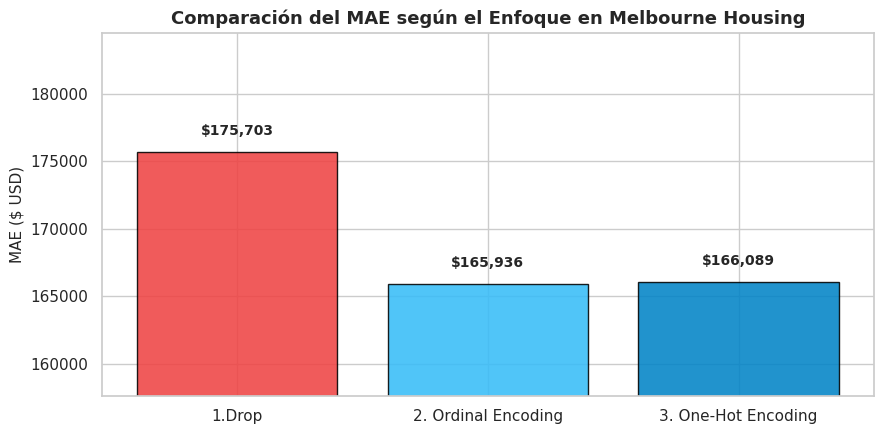

In [73]:
# Tabla comparativa de los tres enfoques básicos
mae_1 = score_dataset(drop_X_train, drop_X_valid, y_train, y_valid)
mae_2 = score_dataset(label_X_train, label_X_valid, y_train, y_valid)
mae_3 = score_dataset(OH_X_train, OH_X_valid, y_train, y_valid)

resumen_melb = pd.DataFrame({
    'Enfoque': [
        '1.Drop',
        '2. Ordinal Encoding',
        '3. One-Hot Encoding'
    ],
    'MAE_USD': [mae_1, mae_2, mae_3]
})

resumen_melb['Diferencia_vs_Drop ($)'] = mae_1 - resumen_melb['MAE_USD']
display(resumen_melb.sort_values(by='MAE_USD'))

# Gráfico comparativo
plt.figure(figsize=(9, 4.5))
colores = ['#ef4444', '#38bdf8', '#0284c7']
bars = plt.bar(resumen_melb['Enfoque'], resumen_melb['MAE_USD'], color=colores, edgecolor='black', alpha=0.88)
plt.title("Comparación del MAE según el Enfoque en Melbourne Housing", fontsize=13, weight='bold')
plt.ylabel("MAE ($ USD)", fontsize=11)
plt.ylim(min(resumen_melb['MAE_USD']) * 0.95, max(resumen_melb['MAE_USD']) * 1.05)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1000, f"${yval:,.0f}", ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

---
### Codificación por Objetivo (*Target Encoding*) 🎯

Si bien One-Hot Encoding funciona de maravilla para características con categorías limitadas (menos de 10 a 20 categorías), a medida que el número de categorías aumenta, los vectores codificados en One-Hot se vuelven más largos y dispersos, lo que potencialmente conduce a un mayor uso de memoria y complejidad computacional. Veamos un ejemplo:

Utilizaremos el **[Dataset de Automóviles de 1985 (Automobiles)](data/autos.csv)**. Consiste en 193 automóviles del modelo 1985. El objetivo para este dataset es predecir el precio del automóvil (el *target*) a partir de 23 características del vehículo, tales como `make` (fabricante), `body_style` (tipo de carrocería) y `horsepower` (caballos de fuerza):

In [70]:
# Cargamos los datos del dataset de automóviles
file_path_autos = 'data/autos.csv'
if not os.path.exists(file_path_autos) and os.path.exists(f'06 - Feature Engineering/{file_path_autos}'):
    file_path_autos = f'06 - Feature Engineering/{file_path_autos}'

if not os.path.exists(file_path_autos):
    print('Descargando dataset autos.csv...')
    os.makedirs(os.path.dirname(file_path_autos), exist_ok=True)
    url = 'https://raw.githubusercontent.com/ricber/data-science-course/master/06-Feature%20Engineering/data/autos.csv'
    urllib.request.urlretrieve(url, file_path_autos)

autos = pd.read_csv(file_path_autos)
autos.head()

,Type,Method,Regionname,Rooms,Distance,Postcode,Bedroom2,Bathroom,Landsize,Lattitude,Longtitude,Propertycount
12167,u,S,Southern Metropolitan,1,5.0,3182.0,1.0,1.0,0.0,-37.85984,144.9867,13240.0
6524,h,SA,Western Metropolitan,2,8.0,3016.0,2.0,2.0,193.0,-37.85800,144.9005,6380.0
8413,h,S,Western Metropolitan,3,12.6,3020.0,3.0,1.0,555.0,-37.79880,144.8220,3755.0
2919,u,SP,Northern Metropolitan,3,13.0,3046.0,3.0,1.0,265.0,-37.70830,144.9158,8870.0
6043,h,S,Western Metropolitan,3,13.3,3020.0,3.0,1.0,673.0,-37.76230,144.8272,4217.0


Un **Target Encoding** es cualquier tipo de codificación que reemplaza las categorías de una variable con algún número derivado de la variable objetivo (*target*).

Una versión simple y muy efectiva es aplicar una agregación de grupo, como la **media (*mean*)**. Utilizando el dataset de Automóviles, esto calcula el precio promedio de la marca de cada vehículo (`make`):

In [71]:
autos["make_encoded"] = autos.groupby("make")["price"].transform("mean")
autos[["make", "price", "make_encoded"]].head(10)

,symboling,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,2,audi,gas,std,4,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,2,audi,gas,std,4,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


Este tipo de target encoding a veces se denomina **mean encoding** (codificación por la media). Aplicado a un objetivo binario, también se le conoce como **bin counting**. 

*(Otros nombres con los que puedes encontrarte en la literatura técnica incluyen: likelihood encoding, impact encoding y leave-one-out encoding).*

---
##### 🛠️ Práctica 4: Creando tu propio Mean Target Encoding

Utilizando el DataFrame `autos`, crea una nueva columna llamada `'body_style_encoded'` que contenga el precio medio agrupado por el tipo de carrocería (`body_style`). Luego, muestra las primeras 5 filas con `[['body_style', 'price', 'body_style_encoded']]`.

In [72]:
# Escribe tu código aquí

# autos['body_style_encoded'] = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
# Calculamos la media del precio agrupado por body_style
autos['body_style_encoded'] = autos.groupby('body_style')['price'].transform('mean')

# Mostramos la comparación
autos[['body_style', 'price', 'body_style_encoded']].head()
```
</details>

---